<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" style="width: 30%;">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Deslocamentos transversais de vigas

### Problema 1

Uma viga simplesmente apoiada está carregada da forma indicada na figura.

a) Utilizando funções de singularidade, escreva as equações do esforço transverso e do momento fletor na viga. Trace os diagramas desses dois esforços.

b) Determine a equação da linha elástica.

c) Se a viga for constituída por um perfil W250 $\times$ 49.1, determine o valor da tensão normal máxima.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au09/P1/MSII_Au09_P1.png"
style="width: 60%;"/>


In [8]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '1'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr2.atoms(sy.Number)})

# data structure, units: N, mm, MPa

class varin: pass

d = varin()
W250 = varin()

d.LAB = 3.  # unit: m
d.LBC = 2.  # unit: m
d.LCD = 2.5  # unit: m
d.LDE = 2.5  # unit: m
d.FB = 500.  # unit: N
d.MD = 100.  # unit: N.m
d.QE = 50. # unit: N/m

d.LCE = d.LCD + d.LDE
d.LAC = d.LAB + d.LBC
d.LAD = d.LAC + d.LCD
d.LAE = d.LAC + d.LCE

W250.tf = 11. # unit: mm
W250.tw = 7.4 # unit: mm
W250.A = 6250. # unit: mm2
W250.Iz = 70.6e6 # unit: mm4
W250.Iy = 15.1e6 # unit: mm4
W250.b = 202. # unit: mm
W250.h = 247. # unit: mm

### Resolução

#### (a) Utilizando funções de singularidade, escreva as equações do esforço transverso e do momento fletor na viga. Trace os diagramas desses dois esforços.


**Equilíbrio estático: cálculo das reacções**
- 1 ::: cálculo das reações

Esquematizando o diagrama de corpo livre, identifique-se todas as forças aplicadas sobre a viga. A análise do equilíbrio estático permitirá determinar as forças de reação desconhecidas,

\begin{equation*}
\sum F_x = 0
\quad\wedge\quad
\sum F_y = 0
\quad\wedge\quad
\sum M_D = 0
\end{equation*}

In [9]:
rax, ray, rey = sy.symbols('rax ray rey')

print('::: sistema de equações :::')
sumFX = rax
d.Q_eq = d.QE*d.LCE/2
d.Q_xcent = d.LAC+(2/3*d.LCE)
print(f'd.Q_eq    = {d.Q_eq} [N]')
print(f'd.Q_xcent = {d.Q_xcent:.3f} [m]')
sumFY = ray + rey - d.FB - d.Q_eq
print(f'sumFY     = {sumFY} [N]')
sumMA= -d.FB*d.LAB -d.Q_eq*d.Q_xcent -d.MD +rey*d.LAE
print(f'sumMA     = {printsymSF(sumMA)} [N.m]')
sol = solve([sumFX,sumFY,sumMA],[rax, ray, rey])

print('\n::: resolução :::')
RAx = sol[rax]; print(f'RAx = {RAx} [N]')
RAy = sol[ray]; print(f'RAy = {RAy:.2f} [N]')
REy = sol[rey]; print(f'REy = {REy:.2f} [N]')

::: sistema de equações :::
d.Q_eq    = 125.0 [N]
d.Q_xcent = 8.333 [m]
sumFY     = ray + rey - 625.0 [N]
sumMA     = 10.0*rey - 2641.667 [N.m]

::: resolução :::
RAx = 0.0 [N]
RAy = 360.83 [N]
REy = 264.17 [N]


**Diagrama de esforços**

- 0 ::: Formulário

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au09/P1/MSII_Au09_P1_formulario.png"
width="900"/>

- **1 :::** Expressão do esforço transverso escrita com base em funções de singularidade

\begin{equation*}
V(x) = R_{Ay} <x-0>^0 - F_B<x-L_{AB}>^0 - \frac{Q_E/L_{CE}}{2}<x-L_{AC}>^2
+ \underbrace{R_{Ey} <x-L_{AE}>^0}_{off}
\end{equation*}

- **2 :::** Expressão do momento fletor escrita com base em funções de singularidade

\begin{equation*}
M(x) = M_D <x-L_{AD}>^0 + R_{Ay} <x-0>^1 - F_B <x-L_{AB}>^1 - \frac{Q_E/L_{CE}}{(2)(3)}<x-L_{AC}>^3
+ \underbrace{R_{Ey} <x-L_{AE}>^1}_{off}
\end{equation*}


In [10]:
x = sy.symbols('x')

VAB = RAy
VBC = RAy - d.FB*(x-d.LAB)**0
VCE = RAy - d.FB*(x-d.LAB)**0 - d.QE/d.LCE/2*(x-d.LAC)**2
print(f'VCE = {printsymSF(VCE)} [N]')

MAB = RAy*x
MBC = RAy*x - d.FB*(x-d.LAB)**1
MCD = RAy*x - d.FB*(x-d.LAB)**1 -   d.QE/d.LCE/2/3*(x-d.LAC)**3
MDE = RAy*x - d.FB*(x-d.LAB)**1 + d.MD*(x-d.LAD)**0 - d.QE/d.LCE/2/3*(x-d.LAC)**3

xAB = np.linspace(0,d.LAB)
xBC = np.linspace(d.LAB,d.LAC)
xCE = np.linspace(d.LAC,d.LAE)
xCD = np.linspace(d.LAC,d.LAD)
xDE = np.linspace(d.LAD,d.LAE)

def sy2array(sygunc,xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

# AB
yVAB = sy2array(VAB,xAB)
yMAB = sy2array(MAB,xAB)

# BC
yVBC = sy2array(VBC,xBC)
yMBC = sy2array(MBC,xBC)

# CE
yVCE = sy2array(VCE,xCE)

# CD+DR
yMCD = sy2array(MCD,xCD)
yMDE = sy2array(MDE,xDE)

VCE = -5.0*x**2 + 50.0*x - 264.167 [N]


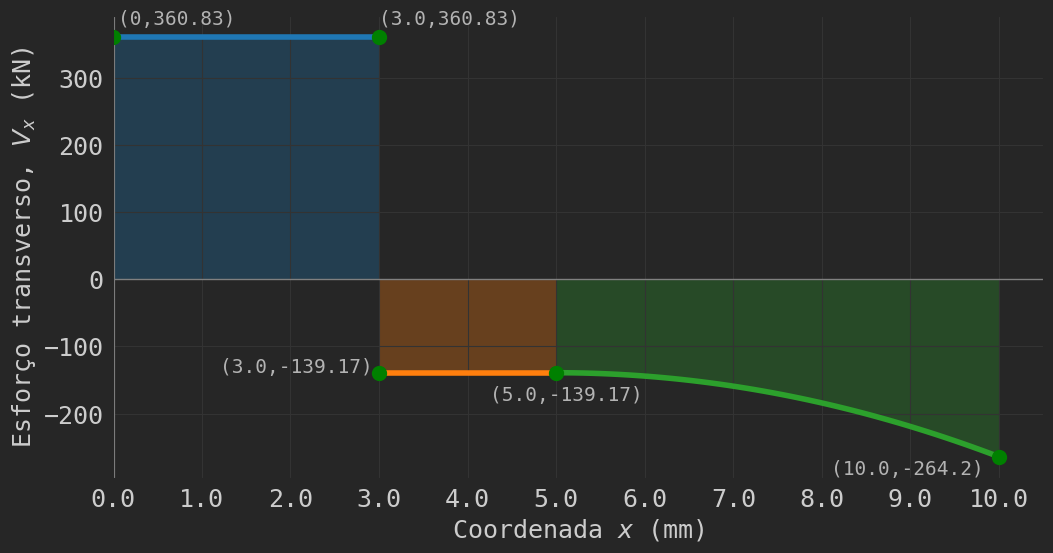

In [11]:
fz = 14

fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=3,color=(.5, .5, .5))
plt.plot(xAB,yVAB,linewidth=4)
plt.fill_between(xAB,yVAB, alpha=.3)
plt.plot(xBC,yVBC,linewidth=4)
plt.fill_between(xBC,yVBC, alpha=.3)
plt.plot(xCE,yVCE,linewidth=4)
plt.fill_between(xCE,yVCE, alpha=.3)
plt.xlabel('Coordenada $x$ (mm)')
plt.ylabel('Esforço transverso, $V_{x}$ (kN)')
plt.plot(xAB[0],yVAB[0],'go',markersize=10)
plt.text(xAB[0]+.05,yVAB[0]*1.05,f'({xAB[0]:.0f},{yVAB[0]:.2f})',fontsize=fz)
plt.plot(xAB[-1],yVAB[-1],'go',markersize=10)
plt.text(xAB[-1]*1.,yVAB[-1]*1.05,f'({xAB[-1]:.1f},{yVAB[-1]:.2f})',
         fontsize=fz)
plt.plot(xBC[0],yVBC[0],'go',markersize=10)
plt.text(xBC[0]*.4,yVBC[0]*1.,f'({xBC[0]:.1f},{yVBC[0]:.2f})',fontsize=fz)
plt.plot(xBC[-1],yVBC[-1],'go',markersize=10)
plt.text(xBC[-1]*.85,yVBC[-1]*1.3,f'({xBC[-1]:.1f},{yVBC[-1]:.2f})',
         fontsize=fz)
plt.plot(xCE[-1],yVCE[-1],'go',markersize=10)
plt.text(xCE[-1]*.81,yVCE[-1]*1.1,f'({xCE[-1]:.1f},{yVCE[-1]:.1f})',
         fontsize=fz)
plt.xlim(0,d.LAE*1.05)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.arange(0, d.LAE*1.1, 1.)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
# plt.ylim(-int(P4.p2*2),int(P4.p2*2))
plt.grid(True)
plt.show()

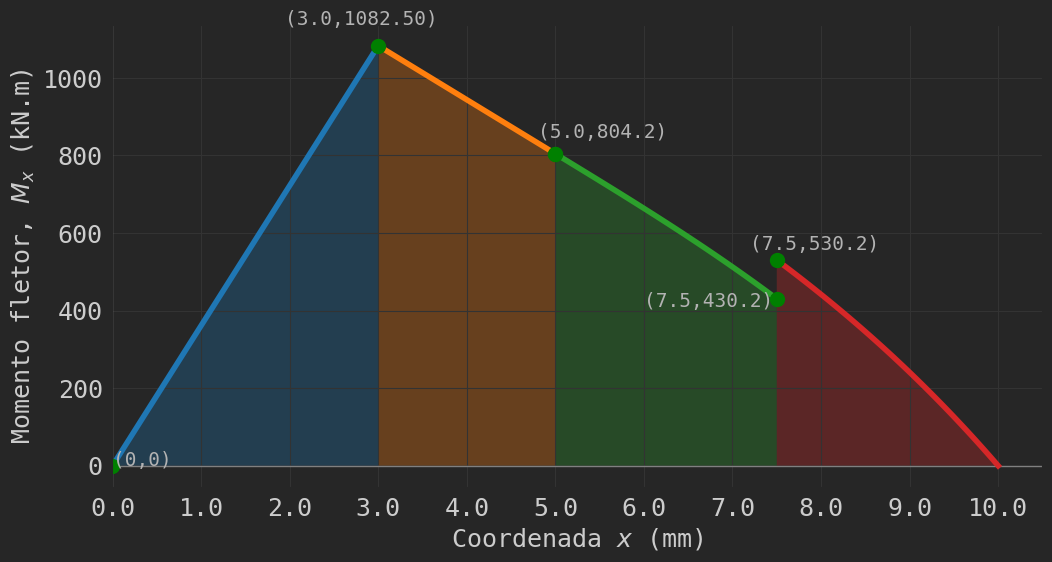

In [12]:
fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=1,color=(.5, .5, .5))
plt.plot(xAB,yMAB,linewidth=4)
plt.fill_between(xAB,yMAB, alpha=.3)
plt.plot(xBC,yMBC,linewidth=4)
plt.fill_between(xBC,yMBC, alpha=.3)
plt.plot(xCD,yMCD,linewidth=4)
plt.fill_between(xCD,yMCD, alpha=.3)
plt.plot(xDE,yMDE,linewidth=4)
plt.fill_between(xDE,yMDE, alpha=.3)
plt.xlabel(r'Coordenada $x$ (mm)')
plt.ylabel(r'Momento fletor, $M_{x}$ (kN.m)')
plt.plot(xAB[0],yMAB[0],'go',markersize=10)
plt.text(xAB[0]+.01,yMAB[0]+.1,f'({xAB[0]:.0f},{yMAB[0]:.0f})',fontsize=fz)
plt.plot(xBC[0],yMBC[0],'go',markersize=10)
plt.text(xBC[0]*.65,yMBC[0]*1.05,f'({xBC[0]:.1f},{yMBC[0]:.2f})',fontsize=fz)
plt.plot(xBC[-1],yMBC[-1],'go',markersize=10)
#plt.text(xBC[-1]*.75,yMBC[-1]-3.5,f'({xBC[-1]:.2f},{yMBC[-1]:.1f})',
# fontsize=fz)
plt.plot(xCD[0],yMCD[0],'go',markersize=10)
plt.text(xCD[0]*.96,yMCD[0]*1.05,f'({xCD[0]:.1f},{yMCD[0]:.1f})',fontsize=fz)
plt.plot(xCD[-1],yMCD[-1],'go',markersize=10)
plt.text(xCD[-1]*.8,yMCD[-1]*.95,f'({xCD[-1]:.1f},{yMCD[-1]:.1f})',fontsize=fz)
plt.plot(xDE[0],yMDE[0],'go',markersize=10)
plt.text(xDE[0]*.96,yMDE[0]*1.05,f'({xDE[0]:.1f},{yMDE[0]:.1f})',fontsize=fz)
plt.xlim(0,d.LAE*1.05)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.arange(0, d.LAE*1.1, 1.0)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
plt.grid(True)
plt.show()

#### (b) Determine a equação da linha elástica.

- **3 :::** Equação da linha elástica:

\begin{equation*}
\frac{\partial² y}{\partial x²} = \frac{M(x)}{EI}
\end{equation*}

com,

\begin{equation*}
M(x) = M_D <x-L_{AD}>^0 + R_{Ay} x - F_B <x-L_{AB}>^1 - \frac{Q_E/L_{CE}}{6
}<x-L_{AC}>^3
\end{equation*}


por integração, obtem-se

\begin{equation*}
EI\theta(x) = M_D <x-L_{AD}>^1 + \frac{R_{Ay}}{2}x² - \frac{F_B}{2}<x-L_{AB}>^2 - \frac{Q_E/L_{CE}}{24
}<x-L_{AC}>^4 + C_1
\end{equation*}

integrando novamente resulta

\begin{equation*}
EIy(x) = \frac{M_D}{2}<x-L_{AD}>^2 + \frac{R_{Ay}}{6}x³ - \frac{F_B}{6}<x-L_{AB}>^3 - \frac{Q_E/L_{CE}}{120
}<x-L_{AC}>^5 + C_1 x + C_2
\end{equation*}

As constantes de integração $C_1$ e $C_2$ são determinadas pelas condições de fronteira.

\begin{equation*}
x = 0 \quad\Rightarrow\quad y(0) = 0
\quad\therefore\quad C_2 = 0
\end{equation*}

\begin{equation*}
x = L \quad\Rightarrow\quad y(L_{AE}) = 0
\quad\therefore\quad
\frac{M_D}{2}(L_{AE}-L_{AD})^2 + \frac{R_{Ay}}{6}(L_{AE})³ - \frac{F_B}{6}(L_{AE}-L_{AB})^3 - \frac{Q_E/L_{CE}}{120
}(L_{AE}-L_{AC})^5 + C_1(L_{AE})  = 0
\end{equation*}

In [13]:
c1, c2 = sy.symbols('c1 c2')

print('::: eq. cond. fronteira :::')

def flex(x):
    if x == 0:
        t1, t3, t4 = 0, 0, 0
        t2 = RAy/6*x**3
    else:
        t1 = d.MD/2*(x-d.LAD)**2
        t2 = RAy/6*x**3
        t3 = - d.FB/6*(x-d.LAB)**3
        t4 = - d.QE/d.LCE/120*(x-d.LAC)**5
    return t1 + t2 + t3 + t4 + c1*x + c2

eqC1 = flex(0.)
print(f'eqC2 = {eqC1}')
sol = solve(eqC1,c2)
C2 = sol[0]
print(f'C2 = {C2} ')

eqC2 = flex(d.LAE).subs(c2,C2)
print(f'eqC2 = {printsymSF(eqC2)} N.m')
sol = solve(eqC2,c1)
C1 = sol[0]
print(f'C1 = {C1:.3f} ')

def eitheta_(x):
    return sy.diff(flex(x).subs({(c1,C1),(c2,C2)}),x)

def eiy_(x):
    return flex(x).subs({(c1,C1),(c2,C2)})

::: eq. cond. fronteira :::
eqC2 = c2
C2 = 0 
eqC2 = 10.0*c1 + 31607.639 N.m
C1 = -3160.764 


#### c) Se a viga for constituída por um perfil W250 $\times$ 49.1, determine o valor da tensão normal máxima.

In [14]:
Mmax = yMAB[-1]
print(f'Mom max = {Mmax:.2f} [N.m]')

def sxx(y): return Mmax/(W250.Iz*1e-12)*y

sigxx = sxx(W250.h/2*1e-3)
print(f'sigxx   = {sigxx*1e-6:.2f} [MPa]')

Mom max = 1082.50 [N.m]
sigxx   = 1.89 [MPa]


### Apêndice A: Equação da elástica

A equação $y(x)$ descreve a posição deformada do eixo da viga devido à ação do momento fletor. Esta equação é conhecida como a equação da linha elástica e pode ser obtida na prática através da solução de uma equação diferencial por dupla integração da equação do momento fletor ao longo da viga. A equação resultante deve ainda satisfazer as condições de fronteira do problema, ou seja, ser cinematicamente admissível. Esta condição permitirá determinar, nomeadamente, as constantes de integração resultantes do processo de integração.

A hipótese de Euler-Bernoulli para o problema de flexão de uma viga conduz à seguinte equação,

\begin{equation*}
\varepsilon_{xx} = -\frac{y}{\rho}
\end{equation*}

Assumindo ainda a lei de Hooke para o comportamento linear elástico do materia, $\sigma_{xx} = E \varepsilon_{xx}$, pode obter-se uma relação entre o momento flector $M(x)$ e o raio de curvatura da superfície neutra da viga $\rho$,

\begin{equation*}
\sigma_{xx} = E \varepsilon_{xx} =
-\frac{yE}{\rho}
\quad\wedge\quad
\sigma_{xx} = -\frac{My}{I_z}
\quad\therefore\quad
\frac{1}{\rho} = \frac{M}{EI_z}
\end{equation*}

Considerando agora a relação entre o raio de curvatura $\rho$ e as segundas derivadas da função $y(x)$, que para pequenos valroes resulta,

\begin{equation*}
\frac{1}{\rho} \approx \frac{\mathrm{d}² y}{\mathrm{d} x²}
\end{equation*}

obtém-se finalmente,

\begin{equation*}
\frac{\mathrm{d}² y}{\mathrm{d} x²}
= \frac{M}{EI_z}
\end{equation*}

Assim sendo, para se obter a equação da elástica da viga do problema, $y(x)$, é necessário:

1. Escrever a equação do momento fletor na viga, $M(x)$ - nomeadamente usando funções de singularidasde;

2. Integrar duas vezes essa equação;

3. Aplicar condições fronteira para calcular as duas constantes que surgem durante a integração.


### Apêndice B: Funções de singularidade

As expressões $⟨x − a⟩^0$, $⟨x − a⟩^1$, $⟨x − a⟩^2$ são designadas por funçoes singulares. Quando $n ≥ 0$,

\begin{equation*}
⟨x − a⟩^n = 
\begin{cases}
(x − a)^n & \quad\text{se } x \ge a \\
0 & \quad\text{se } x < a \\
\end{cases}
\end{equation*}

Nota-se que, os parênteses angulares ⟨ ⟩ devem ser substituídos por parênteses curvos ( ) quando $x ≥ a$ e por zero quando $x < a$.

Segue da definição de funções singularidades que,

\begin{equation*}
\int ⟨x − a⟩^n \mathrm{d}x = \frac{1}{n+1} 
⟨x − a⟩^{n+1} \quad\textrm{se}\quad n \ge 0
\end{equation*}

e 

\begin{equation*}
\frac{d}{dx} ⟨x − a⟩^n = n⟨x − a⟩^{n-1} \quad\textrm{se}\quad n \ge 1
\end{equation*}

### Anexo: Funções de singularidade

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Formulario/singularity_functions.png"
width="900">

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>